# Chapter 9: Model Optimization and Compression

*Deep Learning Crash Course - BPB Publications*

We compress a small CNN with magnitude pruning, post-training INT8 quantization, quantization-aware training and knowledge distillation. Each section measures the **three deployment quantities** that matter: model size on disk, inference latency and accuracy.


## 1. Setup and a small reference model

In [1]:
import os, time, copy, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

IMG_DIR = Path('images'); IMG_DIR.mkdir(exist_ok=True)
def set_seed(s=42):
    os.environ['PYTHONHASHSEED']=str(s); random.seed(s); np.random.seed(s)
    try:
        import torch; torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    except ModuleNotFoundError: pass
set_seed(42)


In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
device = 'cpu'  # most compression APIs are CPU-only in PyTorch

tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train = DataLoader(datasets.MNIST('./data', train=True, download=True, transform=tf), batch_size=128, shuffle=True)
test  = DataLoader(datasets.MNIST('./data', train=False, download=True, transform=tf), batch_size=512)

class SmallCNN(nn.Module):
    # QuantStub / DeQuantStub mark the float<->quantized boundaries used by
    # PyTorch's quantization-aware training pipeline. They are no-ops in float
    # mode, so the same class is used by both the baseline and the QAT examples.
    def __init__(self):
        super().__init__()
        self.quant = torch.quantization.QuantStub()
        self.dequant = torch.quantization.DeQuantStub()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10))
    def forward(self, x):
        x = self.quant(x)
        x = self.classifier(self.features(x))
        return self.dequant(x)

def train_model(model, epochs=1, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    for ep in range(epochs):
        model.train()
        for xb, yb in train:
            opt.zero_grad(); loss = loss_fn(model(xb), yb); loss.backward(); opt.step()
    return model

def evaluate(model, loader=test):
    model.eval(); correct = 0; total = 0
    with torch.no_grad():
        for xb, yb in loader:
            correct += (model(xb).argmax(1) == yb).sum().item(); total += yb.size(0)
    return correct / total

def model_size_mb(model, path='./tmp.pt'):
    torch.save(model.state_dict(), path)
    size = os.path.getsize(path) / 1e6
    os.remove(path)
    return size

def latency(model, n=200):
    model.eval()
    x = torch.randn(1, 1, 28, 28)
    with torch.no_grad():
        for _ in range(10): model(x)
        t0 = time.perf_counter()
        for _ in range(n): model(x)
        return (time.perf_counter() - t0) / n * 1e3  # ms

baseline = SmallCNN()
train_model(baseline, epochs=1)
print(f'Baseline | accuracy {evaluate(baseline):.4f} | size {model_size_mb(baseline):.2f} MB | latency {latency(baseline):.2f} ms')


Baseline | accuracy 0.9829 | size 1.69 MB | latency 0.34 ms


## 2. Magnitude pruning

Remove the smallest-magnitude weights from each layer. PyTorch's `torch.nn.utils.prune` stores the pruning mask alongside the original weights.

In [3]:
import torch.nn.utils.prune as prune

def prune_global(model, amount=0.5):
    params = [(m, 'weight') for m in model.modules() if isinstance(m, (nn.Linear, nn.Conv2d))]
    prune.global_unstructured(params, pruning_method=prune.L1Unstructured, amount=amount)
    for module, _ in params:
        prune.remove(module, 'weight')  # bake mask into weights
    return model

def sparsity(model):
    total = zeros = 0
    for m in model.modules():
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            total += m.weight.numel(); zeros += (m.weight == 0).sum().item()
    return zeros / total

pruned = prune_global(copy.deepcopy(baseline), amount=0.5)
print(f'After 50% prune: sparsity {sparsity(pruned):.2f} | accuracy {evaluate(pruned):.4f}')
# A quick fine-tune to recover any accuracy lost
train_model(pruned, epochs=1, lr=1e-4)
print(f'After 1 epoch fine-tune: accuracy {evaluate(pruned):.4f}')


After 50% prune: sparsity 0.50 | accuracy 0.9832
After 1 epoch fine-tune: accuracy 0.9885


## 3. Post-training dynamic quantization (INT8)

Dynamic quantization replaces `nn.Linear` weights with int8 at load time. Activations stay in float32. This is the cheapest form of quantization and works well for MLP- and Transformer-style models.

In [4]:
quant_dynamic = torch.quantization.quantize_dynamic(
    copy.deepcopy(baseline), {nn.Linear}, dtype=torch.qint8)
print(f'Dynamic INT8 | accuracy {evaluate(quant_dynamic):.4f} | size {model_size_mb(quant_dynamic):.2f} MB | latency {latency(quant_dynamic):.2f} ms')


/tmp/ipykernel_616539/3790255184.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quant_dynamic = torch.quantization.quantize_dynamic(


Dynamic INT8 | accuracy 0.9827 | size 0.48 MB | latency 0.51 ms


## 4. Quantization-aware training (QAT)

QAT inserts fake-quant nodes during training so the model learns weights that still work after rounding. It recovers most of the accuracy lost in post-training quantization on hard-to-quantize layers.

In [5]:
qat = SmallCNN()
qat.qconfig = torch.quantization.get_default_qat_qconfig('x86')
qat = torch.quantization.prepare_qat(qat.train())
train_model(qat, epochs=1)
qat.eval(); qat_quant = torch.quantization.convert(qat)
print(f'QAT INT8 | accuracy {evaluate(qat_quant):.4f} | size {model_size_mb(qat_quant):.2f} MB')


/tmp/ipykernel_616539/439596285.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  qat = torch.quantization.prepare_qat(qat.train())
/home/samaresh/src/.venv/lib/python3.12/site-packages/torch/ao/quantization/observer.py:534: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a futur

QAT INT8 | accuracy 0.9786 | size 0.43 MB


## 5. Knowledge distillation

A small *student* network learns to match the *teacher's* soft labels - a Kullback-Leibler divergence between teacher and student softmax outputs at temperature $T$.

In [6]:
import torch.nn.functional as F

class TinyStudent(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(), nn.Linear(28 * 28, 64), nn.ReLU(), nn.Linear(64, 10))
    def forward(self, x): return self.net(x)

def distill_loss(student_logits, teacher_logits, labels, T=4.0, alpha=0.7):
    soft = F.kl_div(F.log_softmax(student_logits / T, dim=1),
                    F.softmax(teacher_logits / T, dim=1), reduction='batchmean') * (T * T)
    hard = F.cross_entropy(student_logits, labels)
    return alpha * soft + (1 - alpha) * hard

teacher = baseline.eval()
student = TinyStudent()
opt = torch.optim.Adam(student.parameters(), lr=1e-3)
for ep in range(1):
    student.train()
    for xb, yb in train:
        with torch.no_grad(): logits_t = teacher(xb)
        logits_s = student(xb)
        loss = distill_loss(logits_s, logits_t, yb)
        opt.zero_grad(); loss.backward(); opt.step()
print(f'Student | accuracy {evaluate(student):.4f} | size {model_size_mb(student):.2f} MB')


Student | accuracy 0.9289 | size 0.21 MB


## 6. Putting it together - a comparison plot

Model                             Acc     MB    Lat(ms)
baseline                       0.9829   1.69       0.40
pruned 50% + fine-tune         0.9885   1.69       0.38
dynamic INT8                   0.9827   0.48       0.66
QAT INT8                       0.9786   0.43       0.61
distilled student              0.9289   0.21       0.13


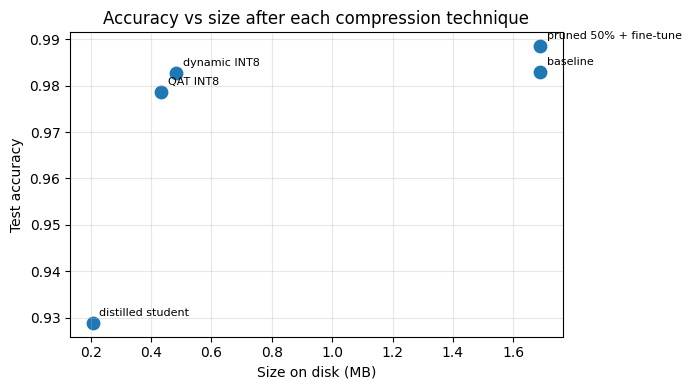

In [7]:
rows = [
    ('baseline', evaluate(baseline), model_size_mb(baseline), latency(baseline)),
    ('pruned 50% + fine-tune', evaluate(pruned), model_size_mb(pruned), latency(pruned)),
    ('dynamic INT8', evaluate(quant_dynamic), model_size_mb(quant_dynamic), latency(quant_dynamic)),
    ('QAT INT8', evaluate(qat_quant), model_size_mb(qat_quant), latency(qat_quant)),
    ('distilled student', evaluate(student), model_size_mb(student), latency(student)),
]
header = ('Model', 'Acc', 'MB', 'Lat(ms)')
print(f'{header[0]:30s} {header[1]:>6s} {header[2]:>6s} {header[3]:>10s}')
for r in rows:
    print(f'{r[0]:30s} {r[1]:6.4f} {r[2]:6.2f} {r[3]:10.2f}')

labels = [r[0] for r in rows]
accs   = [r[1] for r in rows]
sizes  = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(sizes, accs, s=80)
for x, y, lab in zip(sizes, accs, labels):
    ax.annotate(lab, (x, y), fontsize=8, xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Size on disk (MB)'); ax.set_ylabel('Test accuracy')
ax.set_title('Accuracy vs size after each compression technique')
ax.grid(alpha=0.3); fig.tight_layout(); fig.savefig(IMG_DIR / '01_size_vs_acc.png', dpi=150); plt.show()


## 7. Exercise solutions

### 7.1 MCQ answer key

| Q | Answer | Why |
|---|--------|-----|
| 1 | (b) Post-training INT8 quantization | One line of code, ~4x size reduction, typically <1 pp accuracy loss. |
| 2 | (b) Hardware cannot exploit unstructured sparsity | Standard kernels iterate every element regardless of zeros. |
| 3 | (b) Aligns the int8 range with the asymmetric float range | Zero-point shifts the int8 grid. |
| 4 | (a) PTQ uses calibration data only, QAT trains with fake-quant | QAT recovers PTQ accuracy losses. |
| 5 | (b) Sub-network with original initialisation can be trained to match the full one | Lottery Ticket Hypothesis. |
| 6 | (b) Spreads softmax mass so the student learns relative rankings | Temperature softens the target. |
| 7 | (b) Depthwise 3x3 conv + 1x1 pointwise conv | Standard MobileNet trick. |
| 8 | (b) SmoothQuant / GPTQ-style activation-aware quantization | Designed for transformer activation outliers. |
| 9 | (b) GPU kernels run asynchronously | Sync forces the host to wait. |
| 10 | (b) Speculative decoding / KV caching | Both yield 2-3x LLM speed-ups. |
| 11 | (b) cuSPARSELt has native kernels for 2:4 sparsity | Generic unstructured sparsity has no hardware support. |


### 7.2 ResNet-152 -> Android 50 ms pipeline
Stage 1 - **knowledge distillation** to a MobileNetV3-Large student: from 60M parameters to ~5M, accuracy gap typically 1-3 pp.
Stage 2 - **structured pruning** of the residual blocks: trim 30-40 percent of channels with iterative pruning + fine-tune.
Stage 3 - **INT8 quantization-aware training** with the Android NNAPI as target: 4x size reduction, another 2-4x speed-up on hardware with INT8 SIMD.
Stage 4 - **ONNX export + TFLite or PyTorch Mobile** with delegate to the NNAPI / GPU delegate. Profile on the actual device.

If still over budget: try a smaller input resolution (224 -> 192 -> 160), then a smaller backbone (MobileNetV3-Small). At this point a **smaller architecture** is cheaper than further compression.

### 7.3 Unstructured vs structured pruning
**Unstructured** pruning sets individual weights to zero. A modern overparameterised model can lose 95 percent of its weights with almost no accuracy drop because the remaining 5 percent forms a Lottery-Ticket-style subnetwork that fits the data. The downside: GEMM kernels still iterate over the zeros, so no real speed-up.

**Structured** pruning removes whole rows, columns, channels or attention heads. The remaining computation is dense and the speed-up is real, but the same percentage of weights removed corresponds to a much larger loss of capacity because you cannot pick which entries inside each unit are most informative.

Implications:
- (a) **CPU deployment**: prefer structured pruning - the only way to translate sparsity into latency wins.
- (b) **A100 GPU with cuSPARSELt**: use 2:4 fine-grained structured sparsity, which gets ~1.5x speed-up at   50 percent sparsity with no accuracy loss.

### 7.4 GPTQ vs AWQ
**GPTQ** approximates layer-wise weight quantization by minimising the reconstruction error of the layer output, using a small calibration set (~128 samples).
**AWQ** identifies which channels carry large activations and *scales* them before quantization so they fit into the int4 grid without losing information; the channels are then rescaled at inference.
Calibration: GPTQ needs labeled examples in the model's typical distribution; AWQ needs only activation statistics.
For a code-completion model fine-tuned on a proprietary codebase, **AWQ** is the safer choice because it preserves the salient outlier activations that contain the codebase-specific style; GPTQ on a general-language calibration set would over-prioritise generic-text channels.

### 7.5 Why PTQ failed on a transformer
Transformer activations have heavy-tailed outliers in a small number of channels (often the residual-stream channels). A symmetric int8 quantization grid wastes most of its dynamic range on a few outliers and rounds the rest of the channels into the same bin, losing precision where the real signal lives.
QAT recovers accuracy by letting the model learn weights that produce smaller outliers. The targeted alternative is **SmoothQuant** (and **AWQ** above), which shifts the difficulty of quantization from activations to weights using a calibration-derived scale, without retraining.

### 7.6 18 ms CPU vs 9 ms NPU - three technical reasons + one ops reason
1. **Dedicated INT8 SIMD** in the NPU vs vectorised CPU: an NPU has 4-8x more multiplier-adders per cycle.
2. **Reduced memory traffic**: NPU operates on tile-sized buffers in on-chip SRAM, avoiding DRAM round-trips.
3. **Fused operators**: NPU drivers fuse Conv + BatchNorm + ReLU into a single hardware kernel, eliminating intermediate writes.

**Operational reason for rejection**: NPU drivers and SDKs are vendor-specific (Qualcomm Hexagon, Apple Neural Engine, Samsung NPU). Shipping an NPU-optimised model means a custom build per device family, much higher QA cost and longer release cycles. If a single CPU build is fast enough, ship that instead.

### 7.7 Two-engineer-week compression budget
Starting model: 280 MB, 410 ms. Target: 40 MB, 60 ms.

**Decision tree:**
1. **Distill** to a 3x smaller architecture. Stop if: distillation lands below 80 percent of the teacher's accuracy.
2. **Static INT8 quantization** with QAT to recover accuracy. Stop if: latency target hit and accuracy delta acceptable.
3. **Structured channel pruning** at 30-50 percent ratio with iterative fine-tune. Stop if: latency drops below 1.5x target.
4. **Operator fusion** + smaller input resolution. Stop if: any of the above leaves you within 20 percent of target.
5. **Abandon further compression** and ship horizontal scaling once: (a) distilled-quantized-pruned still > 80 MB or > 100 ms, AND (b) further compression is below 0.5 pp accuracy per week of work. At that point a 2-replica deployment is cheaper than another month of engineering.

---
*End of Chapter 9.*
